Simulation examples for validation chapter


In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from IPython.display import Image
from pgmpy.utils import get_example_model
from tigramite.data_processing import DataFrame
from tigramite.toymodels.structural_causal_processes import structural_causal_process
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr


IMAGE_DIR = Path('../../book/book/images')

## graphical modeling

- use the graph structure from ecoli70 (https://www.bnlearn.com/bnrepository/gaussian-medium.html#ecoli70) via pgmpy
- convert to a tigramite model for data generation
- generate timeseries from the graph structure
- use PCMPI to perform causal discovery
- compare to ground truth

46 nodes in the E. coli model.
70 edges in the E. coli model.


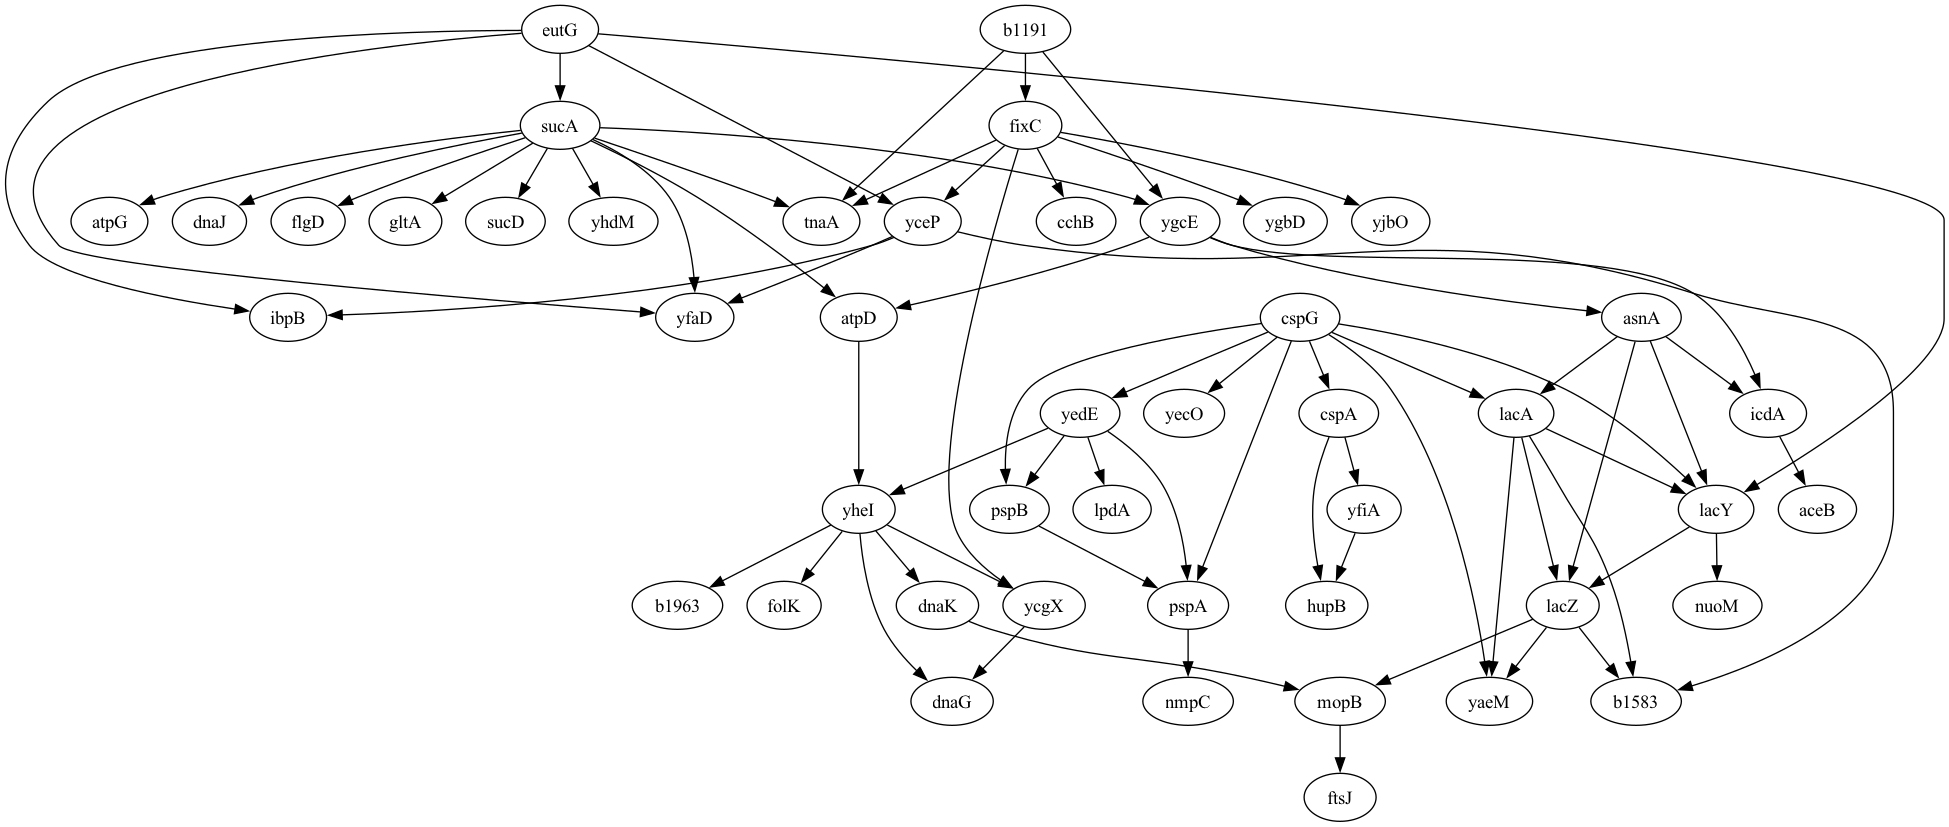

In [3]:
# Load the model
ecoli_model = get_example_model('ecoli70')

# get nodes and edges
nodes = ecoli_model.nodes()
print(f'{len(nodes)} nodes in the E. coli model.')
edges = ecoli_model.edges()
print(f'{len(edges)} edges in the E. coli model.')
cpds = ecoli_model.get_cpds()

# Visualize the network
viz = ecoli_model.to_graphviz()
viz.draw(IMAGE_DIR / 'ecoli.png', prog='dot')
Image(IMAGE_DIR / 'ecoli.png')

In [ ]:
# put this into a tigramite model
# Define links: {effect_var: [((cause_var, lag), coef, noise_func), ...]}
# links = {
#     0: [((0, -1), 0.7, None), ((1, -1), 0.3, None)],
#     1: [((1, -1), 0.8, None)],
# }

def generate_links_from_pgmpy_model(model, coef=0.5, ar_param=0.6):
    nodes, edges = model.nodes(), model.edges()
    noise_func = lambda x: x 
    links = {}

    # create dicts mapping node names to indices and vice versa
    node_to_index = {node: idx for idx, node in enumerate(nodes)}
    index_to_node = {idx: node for node, idx in node_to_index.items()}

    # add edges from the pgmpy model
    for edge in edges:
        cause = node_to_index[edge[0]]
        effect = node_to_index[edge[1]]
        # for simplicity, use lag 1, constant coef and no edge noise
        links.setdefault(effect, []).append( ((cause, -1), coef, noise_func) )

    # add a self-connection to all nodes to simulate autoregressive behavior
    for node in nodes:
        idx = node_to_index[node]
        links.setdefault(idx, []).append( ((idx, -1), ar_param, noise_func) )

    return links, node_to_index, index_to_node

def generate_data(model, noise_sd=1, tslength=500, seed=42, coef=0.5, ar_param=0.6):
    links, node_to_index, index_to_node = generate_links_from_pgmpy_model(model, 
        coef=coef, ar_param=ar_param)
    rng = np.random.default_rng(seed)
    # Calculate total length including transient period
    data, _ = structural_causal_process(links, T=tslength, seed=seed)
    data = rng.normal(scale=noise_sd, size=data.shape) + data
    # Prepare data for tigramite
    return DataFrame(data), index_to_node

# we will need the indx_to_node mapping later
ecoli_dataframe, index_to_node = generate_data(ecoli_model, noise_sd=1, 
    tslength=500, seed=42)

In [5]:
def run_pcmci(dataframe):
    # Initialize PCMCI with partial correlation-based independence test
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=ParCorr())
    # Run PCMCI to discover causal links
    results = pcmci.run_pcmci(tau_max=1, pc_alpha=None)
    # get FDR-corrected p-values
    results['fdr_p_matrix'] = pcmci.get_corrected_pvalues(
        p_matrix=results['p_matrix'], fdr_method='fdr_bh')
    return results

results = run_pcmci(ecoli_dataframe)

In [6]:
# create tuples of x/y pairs from the results
def extract_discovered_links(results, index_to_node, q_thresh=0.00001):
    discovered_links = []
    fdr_p = results['fdr_p_matrix'][:, :, 1]  # use only lag 1 p-values
    links = np.where(fdr_p < q_thresh)
    for (i, j) in zip(links[0], links[1]):
        if not i == j:
            discovered_links.append((index_to_node[i], index_to_node[j]))
    return discovered_links

discovered_links = extract_discovered_links(results, index_to_node, .01)

In [16]:
def get_edge_stats(edges, discovered_links, verbose=True):
    true_edges = set(edges)
    discovered_edges = set(discovered_links)
    true_positives = true_edges.intersection(discovered_edges)
    false_positives = discovered_edges.difference(true_edges)
    false_negatives = true_edges.difference(discovered_edges)

    true_positive_rate = len(true_positives) / len(true_edges) if len(true_edges) > 0 else 0
    
    # Precision: proportion of discoveries that are true
    precision = len(true_positives) / len(discovered_edges) if len(discovered_edges) > 0 else 0
    
    # False Discovery Rate: proportion of discoveries that are false
    false_discovery_rate = len(false_positives) / len(discovered_edges) if len(discovered_edges) > 0 else np.nan
    
    f1_score = (2 * len(true_positives)) / (2 * len(true_positives) + \
        len(false_positives) + len(false_negatives)) if (len(true_positives) + len(false_positives) + len(false_negatives)) > 0 else np.nan
    
    if verbose:
        print(f'{len(true_edges)} true edges')
        print(f'discovered {len(discovered_edges)} edges')
        print(f"True Positive Rate (Recall): {true_positive_rate:.2%}")
        print(f"Precision: {precision:.2%}")
        print(f"False Discovery Rate: {false_discovery_rate:.2%}")
        print(f"F1 Score: {f1_score:.2%}")

    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'true_positive_rate': true_positive_rate,
        'precision': precision,
        'false_discovery_rate': false_discovery_rate,
        'f1_score': f1_score
    }

edge_stats = get_edge_stats(ecoli_model.edges(), discovered_links)

70 true edges
discovered 87 edges
True Positive Rate (Recall): 100.00%
Precision: 80.46%
False Discovery Rate: 19.54%
F1 Score: 89.17%


In [ ]:
# loop over signal levels and q values to see effect on performance

noise_sd = 1
tslength = 500
q_values =  [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
signal_levels = np.arange(0, 0.7, 0.1)
performance_results = []

for signal_level in signal_levels:
    dataframe, index_to_node = generate_data(ecoli_model, noise_sd=noise_sd, tslength=tslength, seed=42, coef=signal_level, ar_param=0.6)
    results = run_pcmci(dataframe)
    for q in q_values:
        discovered_links = extract_discovered_links(results, index_to_node, q_thresh=q)
        edge_stats = get_edge_stats(ecoli_model.edges(), discovered_links, verbose=False)
        performance_results.append({
        'noise_sd': noise_sd,
        'q_value': q,
        'tslength': tslength,
        'signal_level': signal_level,
        'true_positive_rate': edge_stats['true_positive_rate'],
        'precision': edge_stats['precision'],
        'false_discovery_rate': edge_stats['false_discovery_rate'],
        'f1_score': edge_stats['f1_score']
    })

performance_df = pd.DataFrame(performance_results)

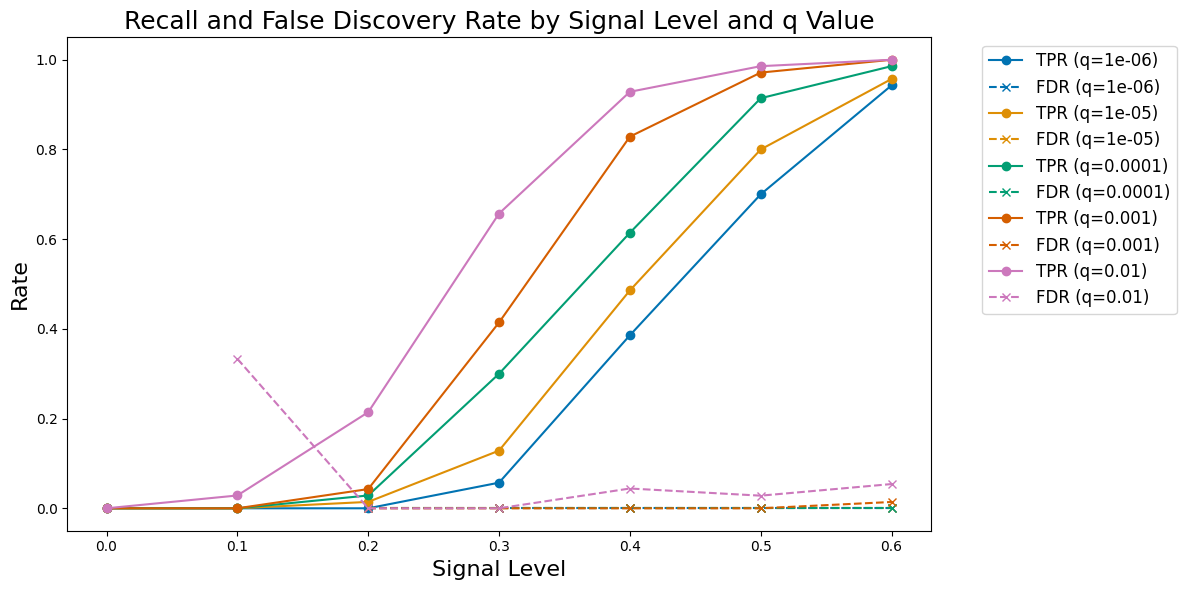

In [23]:
# plot true and false positive rates as a function of tslength and q value
# use log scale for q value
# use a colorblind-friendly palette


# Use colorblind-friendly palette
colors = sns.color_palette("colorblind", n_colors=len(noise_sds))

plt.figure(figsize=(12, 6))
for idx, q in enumerate(q_values):
    subset = performance_df[performance_df['q_value'] == q]
    plt.plot(subset['signal_level'], subset['true_positive_rate'], 
             marker='o', color=colors[idx], linestyle='-',
             label=f'TPR (q={q})')
    plt.plot(subset['signal_level'], subset['false_discovery_rate'], 
             marker='x', color=colors[idx], linestyle='--',
             label=f'FDR (q={q})')

# plt.xscale('log')
plt.xlabel('Signal Level', fontsize=16)
plt.ylabel('Rate', fontsize=16)
plt.title('Recall and False Discovery Rate by Signal Level and q Value', fontsize=18)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'causal_discovery_performance.png', dpi=150, bbox_inches='tight')
plt.show()
